Import Statements

In [2]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import czifile
from skimage import exposure
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import remove_small_objects

PARAMETERS

In [3]:
IMAGE_FOLDER   = "102225_MFI_lipid_droplet_starvation"
FILE_EXTENSION = "*.czi"
RESULTS_FOLDER = "Results"

SWAP_CHANNELS = False

#lipid thresholds
MINIMUM_LIPID_THRESH = 0.25

OUTPUT_FILENAME = "102225_lipid_mfi_per_image.csv"

os.makedirs(RESULTS_FOLDER, exist_ok=True)
print("Parameters set.")

Parameters set.


Helper Functions

In [4]:
def normalize_image(image): #returns normalized image
    """Min-max normalize to float64 [0, 1]."""
    img = image.astype(np.float64)
    mn, mx = img.min(), img.max()
    return np.zeros_like(img) if mx == mn else (img - mn) / (mx - mn)


def boost_contrast_visual(image): #returns image with improved exposure
    """Percentile stretch for DISPLAY ONLY."""
    p_lo, p_hi = np.percentile(image, (1, 99.5))
    return exposure.rescale_intensity(image, in_range=(p_lo, p_hi))


def load_channels(filepath):
    """Load .czi and return (green_raw, red_raw) as 2D arrays."""
    try:
        czi = czifile.CziFile(filepath)
        img = np.squeeze(czi.asarray())
    except Exception as e:
        print(f"  [ERROR] File load failed: {e}")
        return None, None

    ch0 = ch1 = None
    if img.ndim == 3 and img.shape[0] in (2, 3, 4):
        ch0, ch1 = img[0], img[1]
    elif img.ndim == 3 and img.shape[-1] in (2, 3, 4):
        ch0, ch1 = img[..., 0], img[..., 1]
    else:
        print(f"  [ERROR] Unexpected shape: {img.shape}")
        return None, None

    return (ch0, ch1) if SWAP_CHANNELS else (ch1, ch0)


def segment_lipids_otsu(red_channel):
    """Otsu-based lipid segmentation on normalized red channel."""
    red_norm = normalize_image(red_channel)
    try:
        otsu_val     = threshold_otsu(red_norm)
        final_thresh = max(otsu_val, MINIMUM_LIPID_THRESH)
    except Exception:
        final_thresh = MINIMUM_LIPID_THRESH
    binary_lipids = red_norm >= final_thresh
    binary_lipids = remove_small_objects(binary_lipids, min_size=10)
    return binary_lipids  # boolean mask


def analyze_MFI(red_channel, lipid_masks):
    """
    Data to Return:
    - # of lipids
    - lipid area
    - lipid MFI
    """
    n_lipids = label(lipid_masks).max()
    lipid_area = np.sum(lipid_masks)
    lipid_mfi = np.mean(red_channel[lipid_masks])

    mfi_data = {
        "n_lipids" : n_lipids,
        "lipid_area" : lipid_area,
        "lipid_mfi" : lipid_mfi,
    }

    return mfi_data #return dict of dicts

Main Loop

Found 16 file(s) in 102225_MFI_lipid_droplet_starvation
Processing M17D_DMEM_lipidtox_red_mitoBFP_01.czi
Lipid Pixels: 1084
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_01.czi
Total Lipids: 10


C:\Users\jmp732\AppData\Local\Temp\ipykernel_23628\2278297017.py:44: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_lipids = remove_small_objects(binary_lipids, min_size=10)


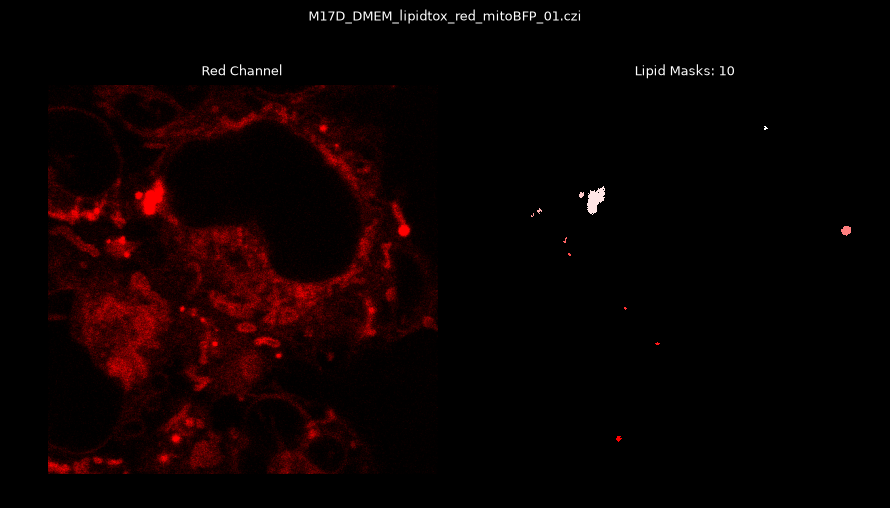

Processing M17D_DMEM_lipidtox_red_mitoBFP_02.czi
Lipid Pixels: 2155
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_02.czi
Total Lipids: 13


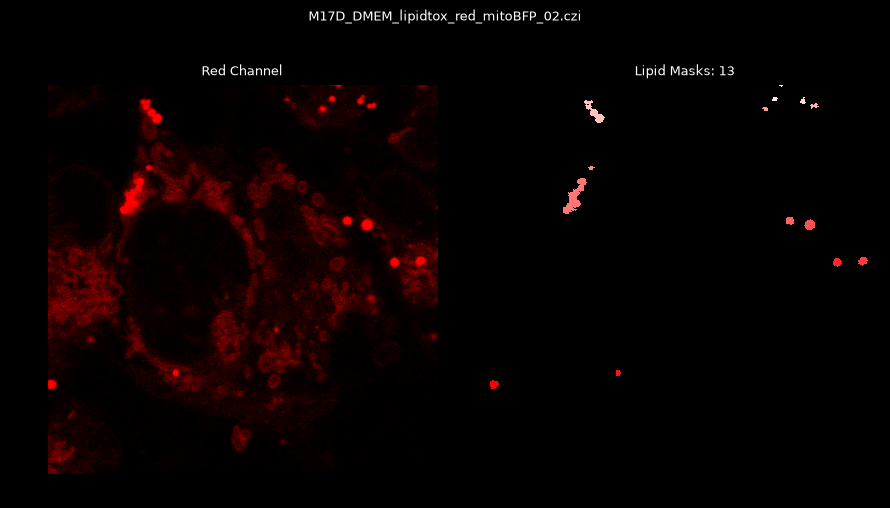

Processing M17D_DMEM_lipidtox_red_mitoBFP_03.czi
Lipid Pixels: 3052
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_03.czi
Total Lipids: 14


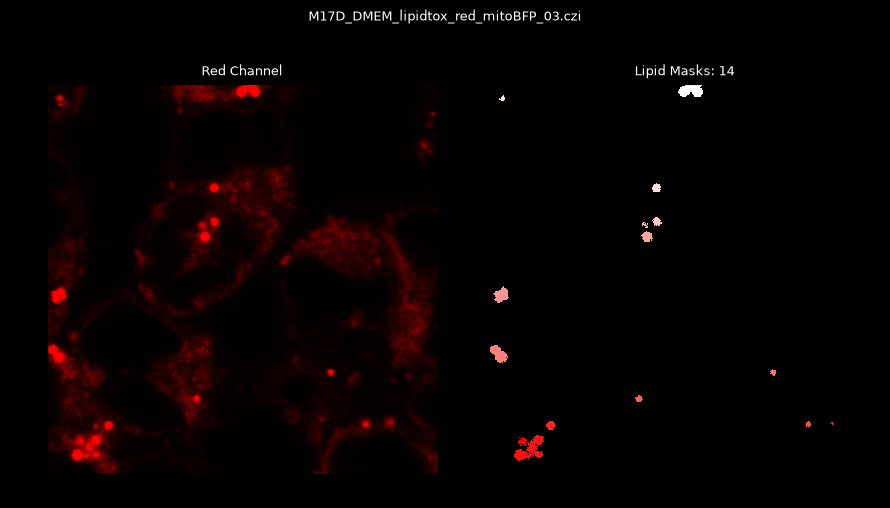

Processing M17D_DMEM_lipidtox_red_mitoBFP_04.czi
Lipid Pixels: 3943
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_04.czi
Total Lipids: 36


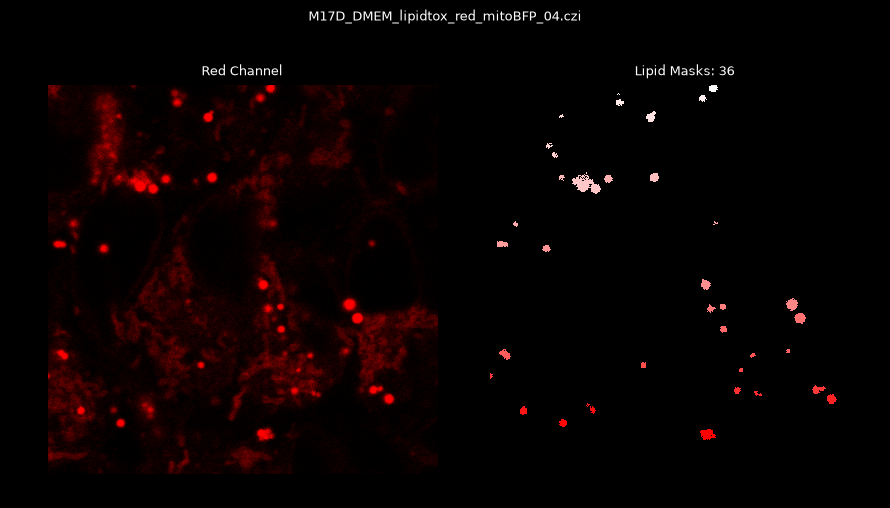

Processing M17D_DMEM_lipidtox_red_mitoBFP_05.czi
Lipid Pixels: 874
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_05.czi
Total Lipids: 9


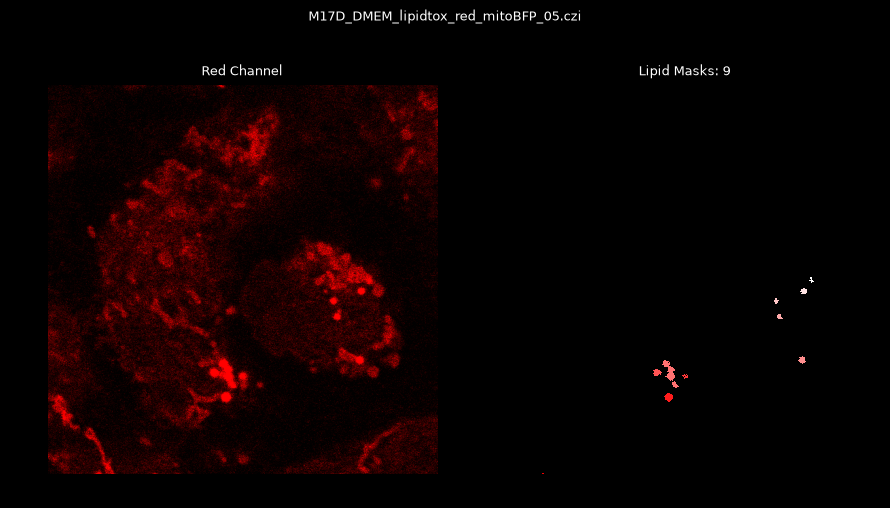

Processing M17D_DMEM_lipidtox_red_mitoBFP_06.czi
Lipid Pixels: 2208
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_06.czi
Total Lipids: 16


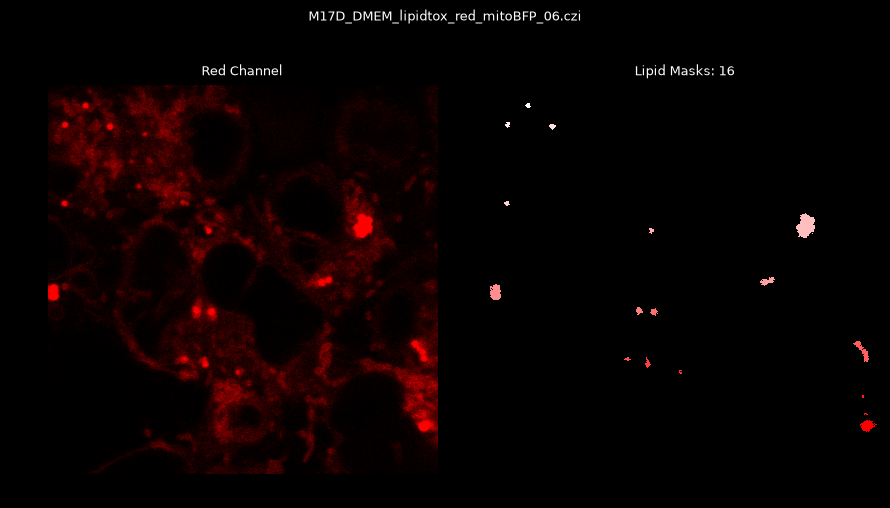

Processing M17D_DMEM_lipidtox_red_mitoBFP_07.czi
Lipid Pixels: 4346
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_07.czi
Total Lipids: 26


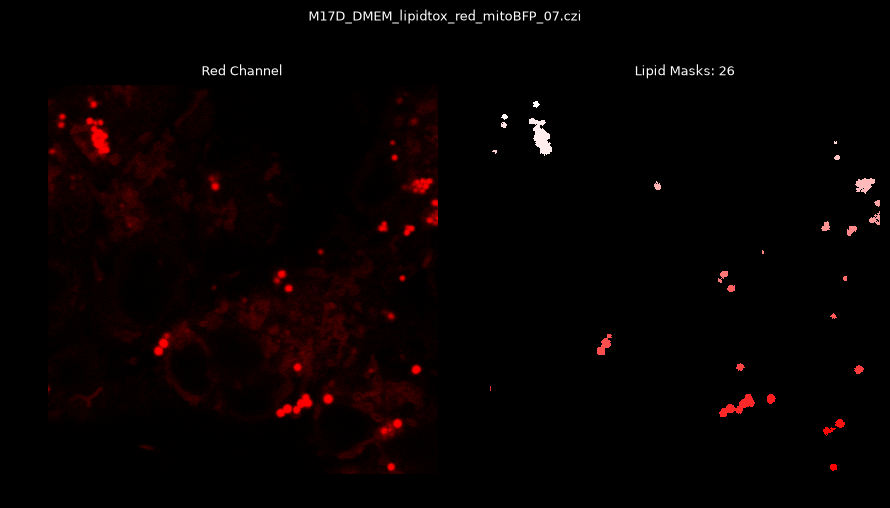

Processing M17D_DMEM_lipidtox_red_mitoBFP_08.czi
Lipid Pixels: 5297
SUMMARY M17D_DMEM_lipidtox_red_mitoBFP_08.czi
Total Lipids: 14


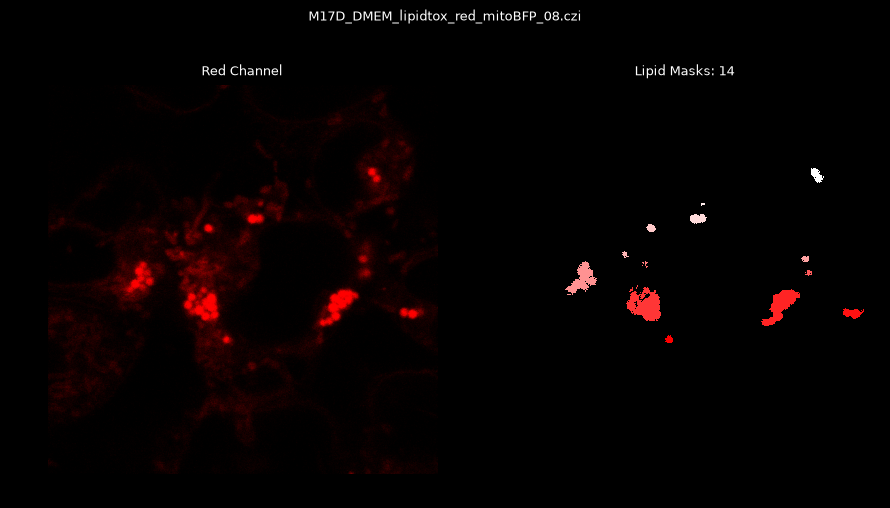

Processing M17D_HBSS_lipidtox_red_mitoBFP_01.czi
Lipid Pixels: 5953
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_01.czi
Total Lipids: 46


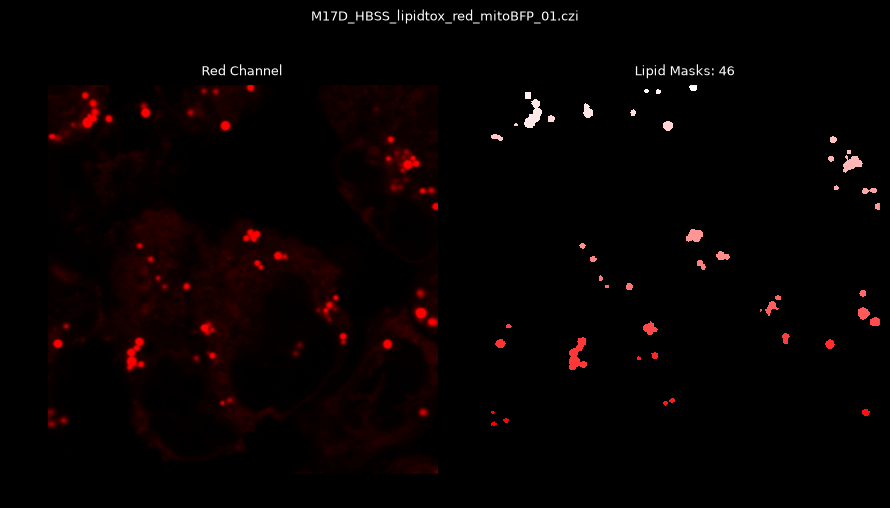

Processing M17D_HBSS_lipidtox_red_mitoBFP_02.czi
Lipid Pixels: 11446
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_02.czi
Total Lipids: 52


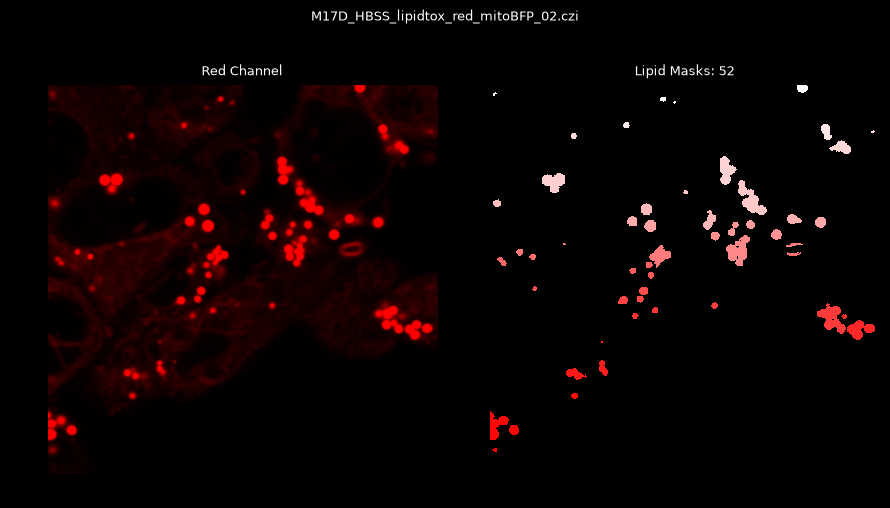

Processing M17D_HBSS_lipidtox_red_mitoBFP_03.czi
Lipid Pixels: 9768
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_03.czi
Total Lipids: 30


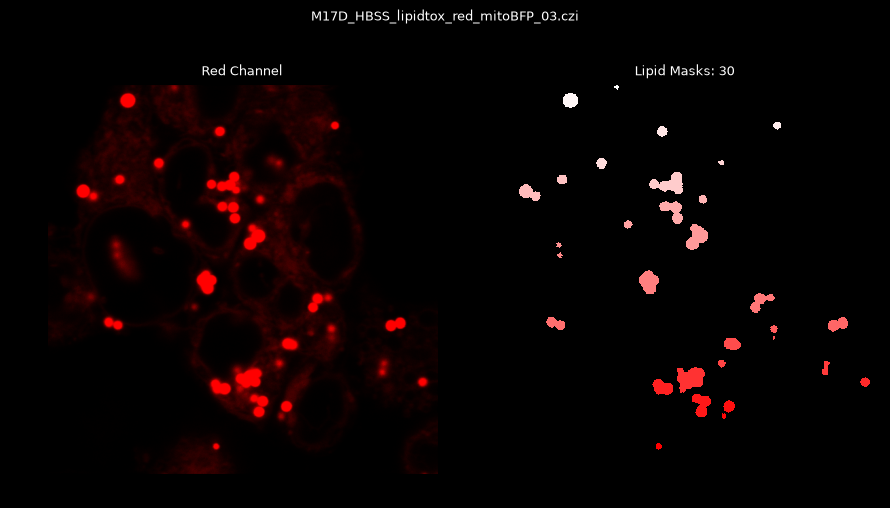

Processing M17D_HBSS_lipidtox_red_mitoBFP_04.czi
Lipid Pixels: 7445
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_04.czi
Total Lipids: 35


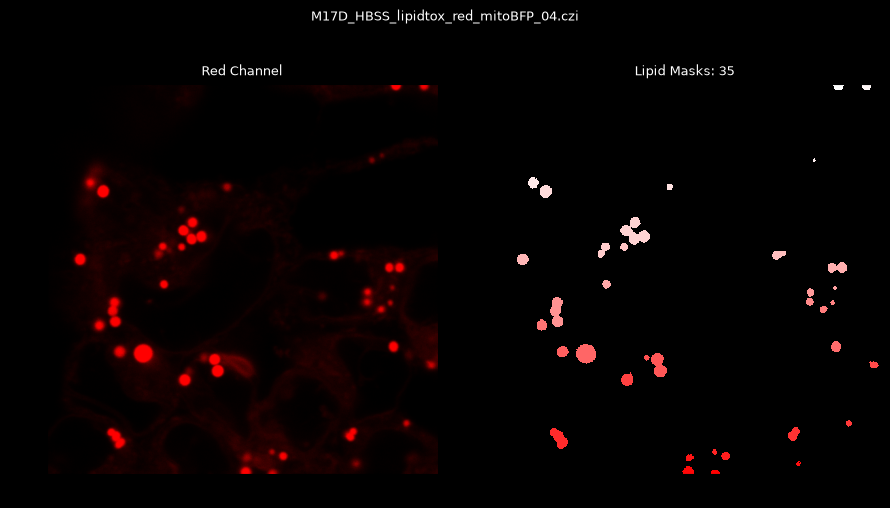

Processing M17D_HBSS_lipidtox_red_mitoBFP_05.czi
Lipid Pixels: 1282
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_05.czi
Total Lipids: 9


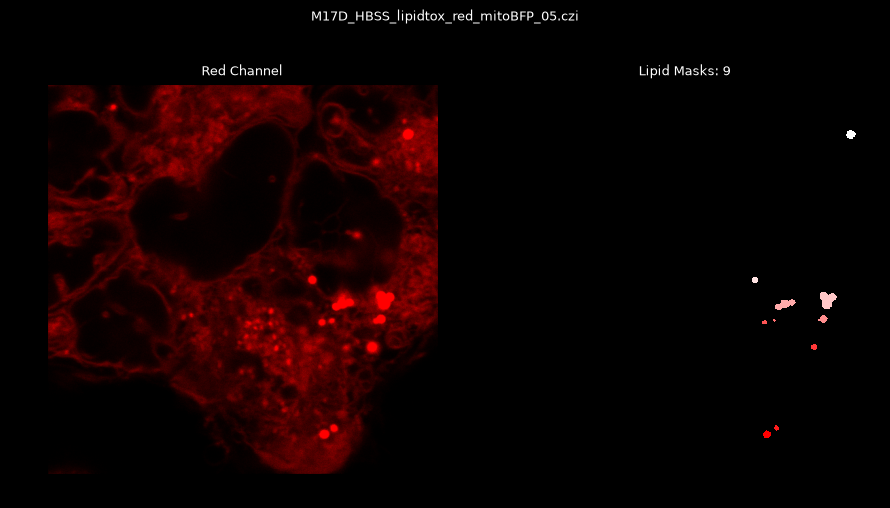

Processing M17D_HBSS_lipidtox_red_mitoBFP_06.czi
Lipid Pixels: 6648
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_06.czi
Total Lipids: 38


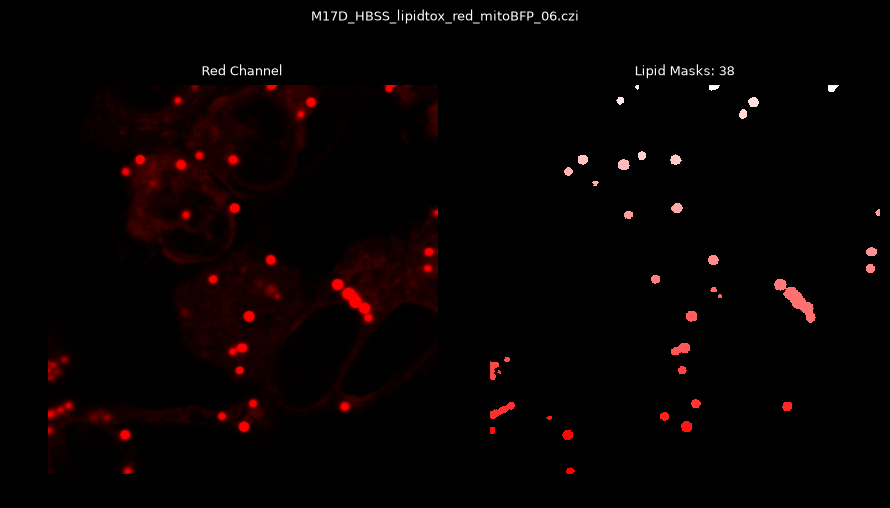

Processing M17D_HBSS_lipidtox_red_mitoBFP_07.czi
Lipid Pixels: 2940
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_07.czi
Total Lipids: 20


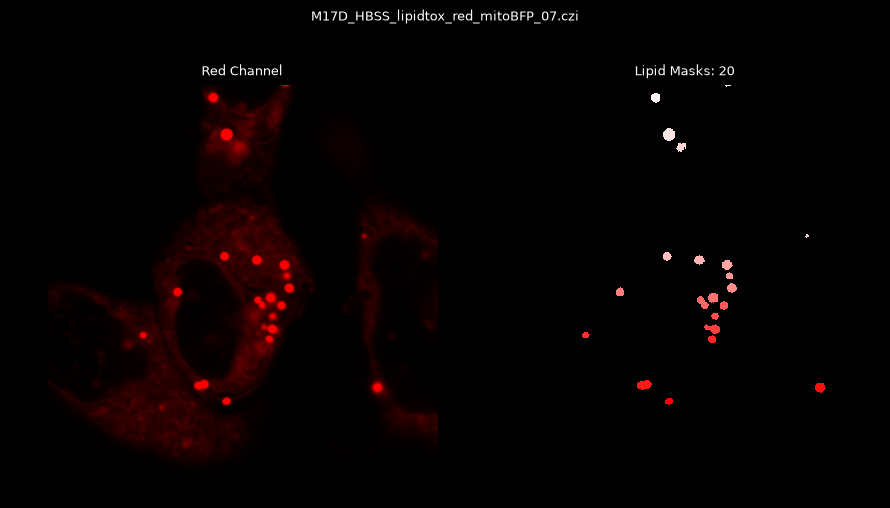

Processing M17D_HBSS_lipidtox_red_mitoBFP_08.czi
Lipid Pixels: 4810
SUMMARY M17D_HBSS_lipidtox_red_mitoBFP_08.czi
Total Lipids: 36


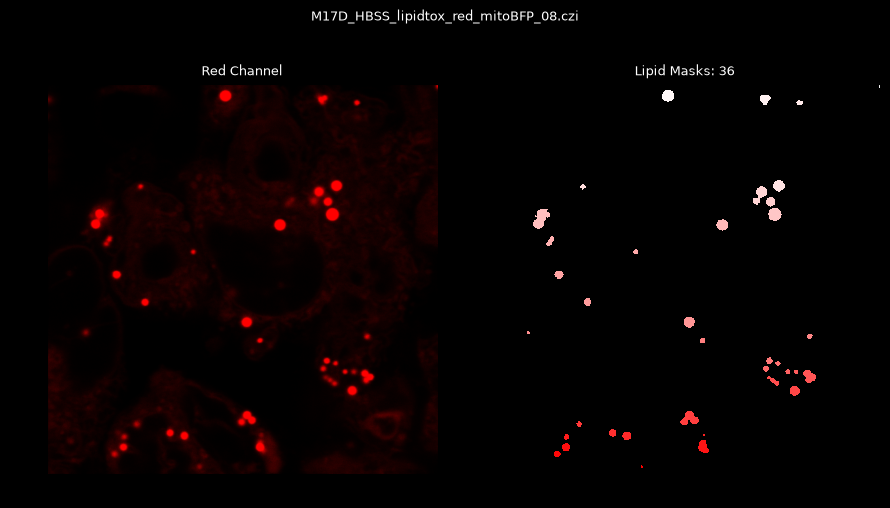

All files processed


In [5]:
# color maps
cmap_red   = LinearSegmentedColormap.from_list("R", [(0,0,0),(1,0,0)])
cmap_red_inv = LinearSegmentedColormap.from_list("RI", [(1, 1, 1),(1,0,0)])

all_results = []

image_files = sorted(glob.glob(os.path.join(IMAGE_FOLDER, FILE_EXTENSION)))
print(f"Found {len(image_files)} file(s) in {IMAGE_FOLDER}")

for filepath in image_files:
    filename = os.path.basename(filepath)
    print(f"Processing {filename}")

    #load channels
    green_raw, red_raw = load_channels(filepath)
    if red_raw is None or green_raw is None:
        print("Load Error: skipping file")
        continue

    adjusted_green = exposure.equalize_hist(green_raw)
    adjusted_red = exposure.equalize_hist(red_raw)
    red_norm = normalize_image(red_raw)
    red_uint8 = (red_norm * 255).astype(np.uint8)
    adjusted_red_uint8 = (adjusted_red * 255).astype(np.uint8)

    #retrieve lipid mask
    lipid_mask = segment_lipids_otsu(red_raw)
    labeled_lipids = label(lipid_mask)
    print(f"Lipid Pixels: {lipid_mask.sum()}")

    #calculate lipid mfi for every cell
    mfi_data = analyze_MFI(red_raw, lipid_mask)

    #summary
    n_lipids = np.max(labeled_lipids) - 1
    print(f"SUMMARY {filename}")
    print(f"Total Lipids: {n_lipids}")

    #visualization
    """
    Plot:
    0: Red Channel
    1: Labeled Lipid Masks
    """
    H, W = lipid_mask.shape
    lipid_display = np.where(labeled_lipids > 0, labeled_lipids, np.nan)
    
    adjusted_green = exposure.equalize_hist(green_raw)
    adjusted_red = exposure.equalize_hist(red_raw)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 5))
    fig.patch.set_facecolor("black")
    fig.suptitle(filename, color="white", fontsize=9, y=1.01)

    axes[0].imshow(boost_contrast_visual(red_raw), cmap=cmap_red)
    axes[0].set_title("Red Channel", color="white", fontsize=9)

    axes[1].set_facecolor("black")
    axes[1].imshow(lipid_display, cmap=cmap_red_inv, interpolation="none")
    axes[1].set_title(f"Lipid Masks: {n_lipids}", color="white", fontsize=9)

    """
    for ax in axes:
        ax.axis("off")
        ax.set_facecolor("black")
    """

    plt.tight_layout()
    plt.show()

    info = mfi_data
    all_results.append({
        "Filename" : filename,
        "# of Lipids" : info["n_lipids"],
        "Lipid Area (px)" : info["lipid_area"],
        "Lipid_MFI" : round(info["lipid_mfi"], 5),
    })

    # break

print("All files processed")


Save Results to CSV

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

if not all_results:
    print("No results to save")
else:
    df = pd.DataFrame(all_results)

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Lipid MFI Per Image"

    headers = list(df.columns)

    header_fill = PatternFill("solid", start_color="C20000")
    header_font = Font(bold=True, color="FFFFFF", name="Arial", size=11)
    center_align = Alignment(horizontal="center", vertical="center")
    left_align = Alignment(horizontal="left", vertical="center")

    thin_border = Border(
        bottom=Side(style="thin", color="AAAAAA"),
        right=Side(style="thin", color="AAAAAA")
    )

    #Header Row
    for col_index, header in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col_index, value=header)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align
        cell.border = thin_border

    ws.row_dimensions[1].height = 34

    alt_fill = PatternFill("solid", start_color="F0D9D6")

    #Data Rows
    for r_idx, row in enumerate(df.itertuples(index=False), start=2):
        fill = alt_fill if r_idx % 2 == 0 else None

        for c_idx, val in enumerate(row, start=1):
            try:
                cell = ws.cell(row=r_idx, column=c_idx, value=val)
            except:
                cellVal = ','.join(str(item) for item in val)
                cell = ws.cell(row=r_idx, column=c_idx, value=cellVal)
            if fill:
                cell.fill = fill
            cell.border = thin_border
            cell.font = Font(name="Arial", size=10)
            cell.alignment = left_align if c_idx == 1 else center_align

    widths = [50, 25, 15, 30]
    for i, w in enumerate(widths, 1):
            ws.column_dimensions[get_column_letter(i)].width = w

    ws.freeze_panes = "A2"

    # Save directly as XLSX
    xlsx_path = os.path.join(RESULTS_FOLDER, OUTPUT_FILENAME.replace(".csv", ".xlsx"))
    wb.save(xlsx_path)

    print(f"Output Saved {xlsx_path}")

Output Saved Results\102225_lipid_mfi_per_image.xlsx
